
# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных

## 1. Загрузка и описание датасета

Импортируем необходимые библиотеки и настраиваем стили графиков

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

Загружаем датасет вин

In [7]:
wine = load_wine()
# Создание DataFrame
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# Добавление целевой переменной (класс вина)
df['target'] = wine.target
df['target_name'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})
print("Первые 5 строк датасета:")
print(df.head())

Первые 5 строк датасета:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prol

### 1.1 Описание набора данных

**Название датасета:** Wine recognition dataset

**Источник:** Scikit-learn library

**Описание:** 
Эти данные являются результатами химического анализа вин, выращенных в одном регионе Италии, но произведенных из трех разных сортов винограда. В анализе определено количество 13 компонентов, содержащихся в каждом из трех типов вин.

**Количество наблюдений:** 178

**Количество признаков:** 13 (все числовые)

**Целевая переменная:** 3 класса вин (0, 1, 2)

**Признаки:**
1. Alcohol - Алкоголь
2. Malic acid - Яблочная кислота
3. Ash - Зольность
4. Alcalinity of ash - Щелочность золы
5. Magnesium - Магний
6. Total phenols - Общие фенолы
7. Flavanoids - Флавоноиды
8. Nonflavanoid phenols - Нефлавоноидные фенолы
9. Proanthocyanins - Проантоцианидины
10. Color intensity - Интенсивность цвета
11. Hue - Оттенок
12. OD280/OD315 of diluted wines - Разбавленные вина
13. Proline - Пролин

## 2. Основные характеристики датасета

In [ ]:
# Основная информация о датасете
print(f"Размерность данных: {df.shape}")
print(f"Количество признаков: {df.shape[1] - 2}") 
print(f"Количество образцов: {df.shape[0]}")
print(f"Количество классов: {len(df['target'].unique())}")
print(f"Распределение по классам:\n{df['target_name'].value_counts()}\n")

Размерность данных: (178, 15)
Количество признаков: 13
Количество образцов: 178
Количество классов: 3
Распределение по классам:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64



In [10]:
# Информация о типах данных и пропущенных значениях
print(df.info())
print("\n")
print("Проверка на пропущенные значения:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Из вывода df.info() видно, что датасет не содержит пропущенных значений, а все признаки имеют числовой тип данных (float64 или int64). df.describe() предоставляет сводную статистику по каждому числовому признаку: количество, среднее, стандартное отклонение, минимальное и максимальное значения, а также квартили.

In [11]:
# Статистическое описание признаков
description = df[wine.feature_names].describe()
display(description)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## 3. Визуальное исследование датасета

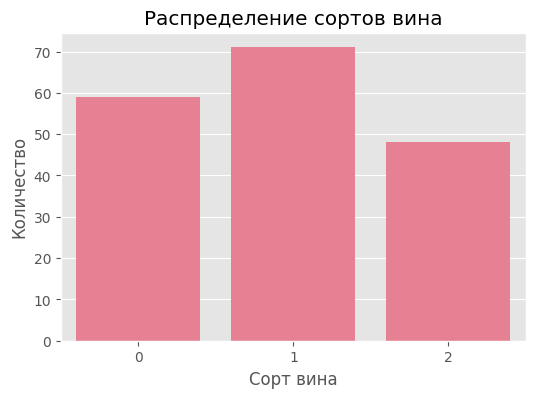

In [17]:
# Распределение вин по сортам
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Распределение сортов вина')
plt.xlabel('Сорт вина')
plt.ylabel('Количество')
plt.show()
     

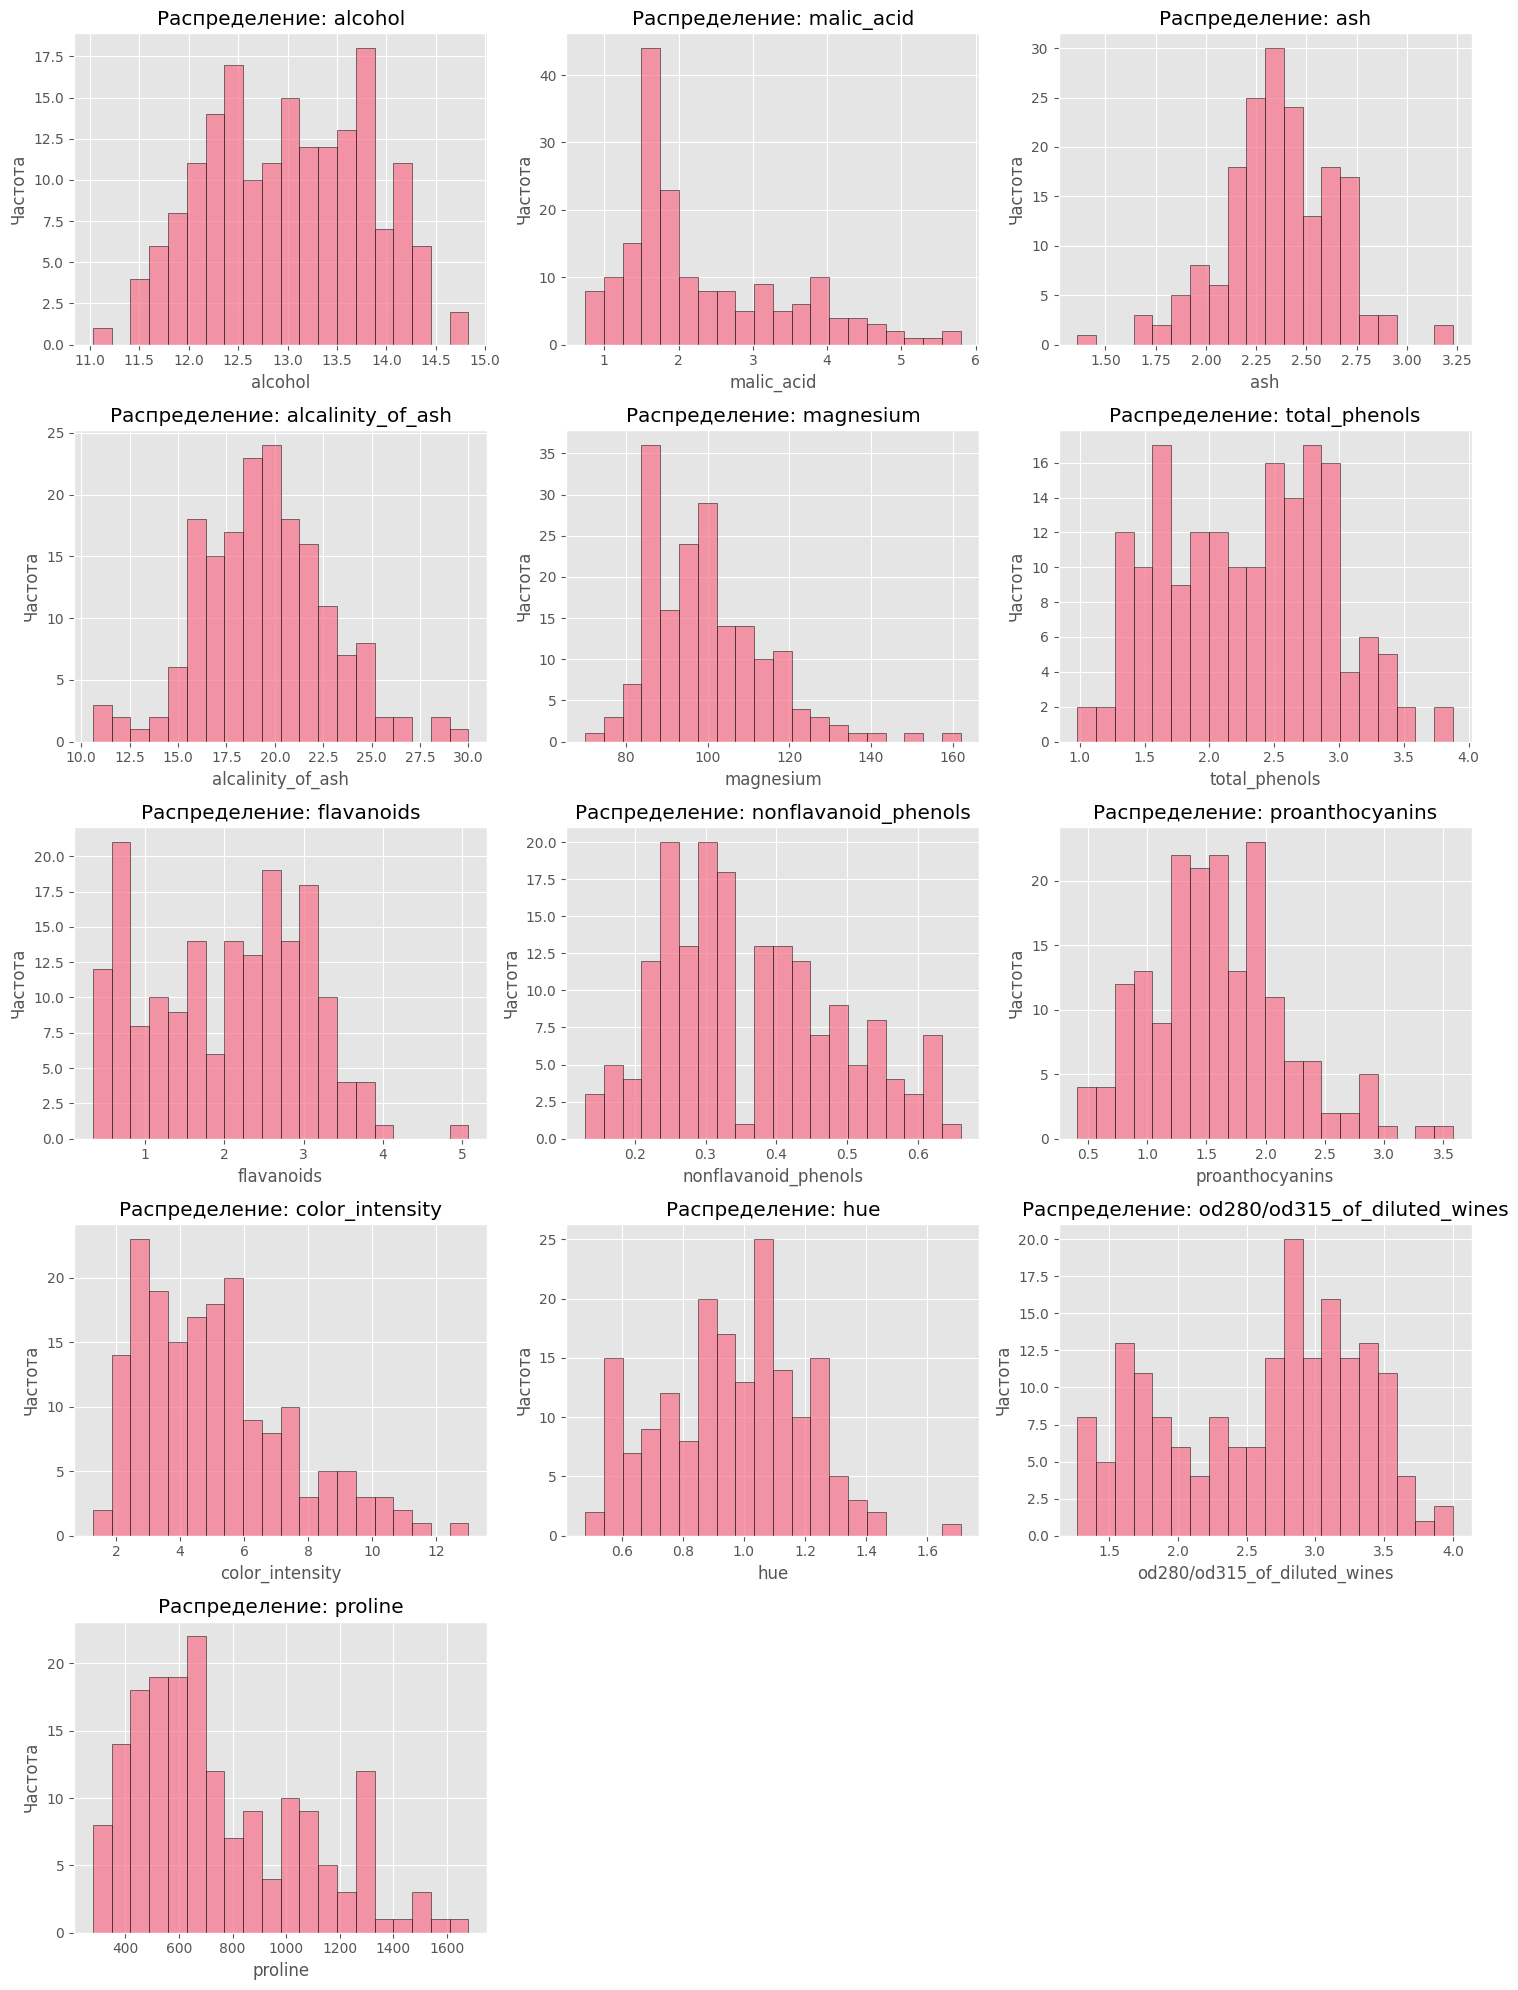

In [12]:
# 3.1 Гистограммы распределения признаков
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.ravel()

for idx, feature in enumerate(wine.feature_names):
    axes[idx].hist(df[feature], bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение: {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Частота')

# Удаляем лишние подграфики (если есть)
for idx in range(len(wine.feature_names), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

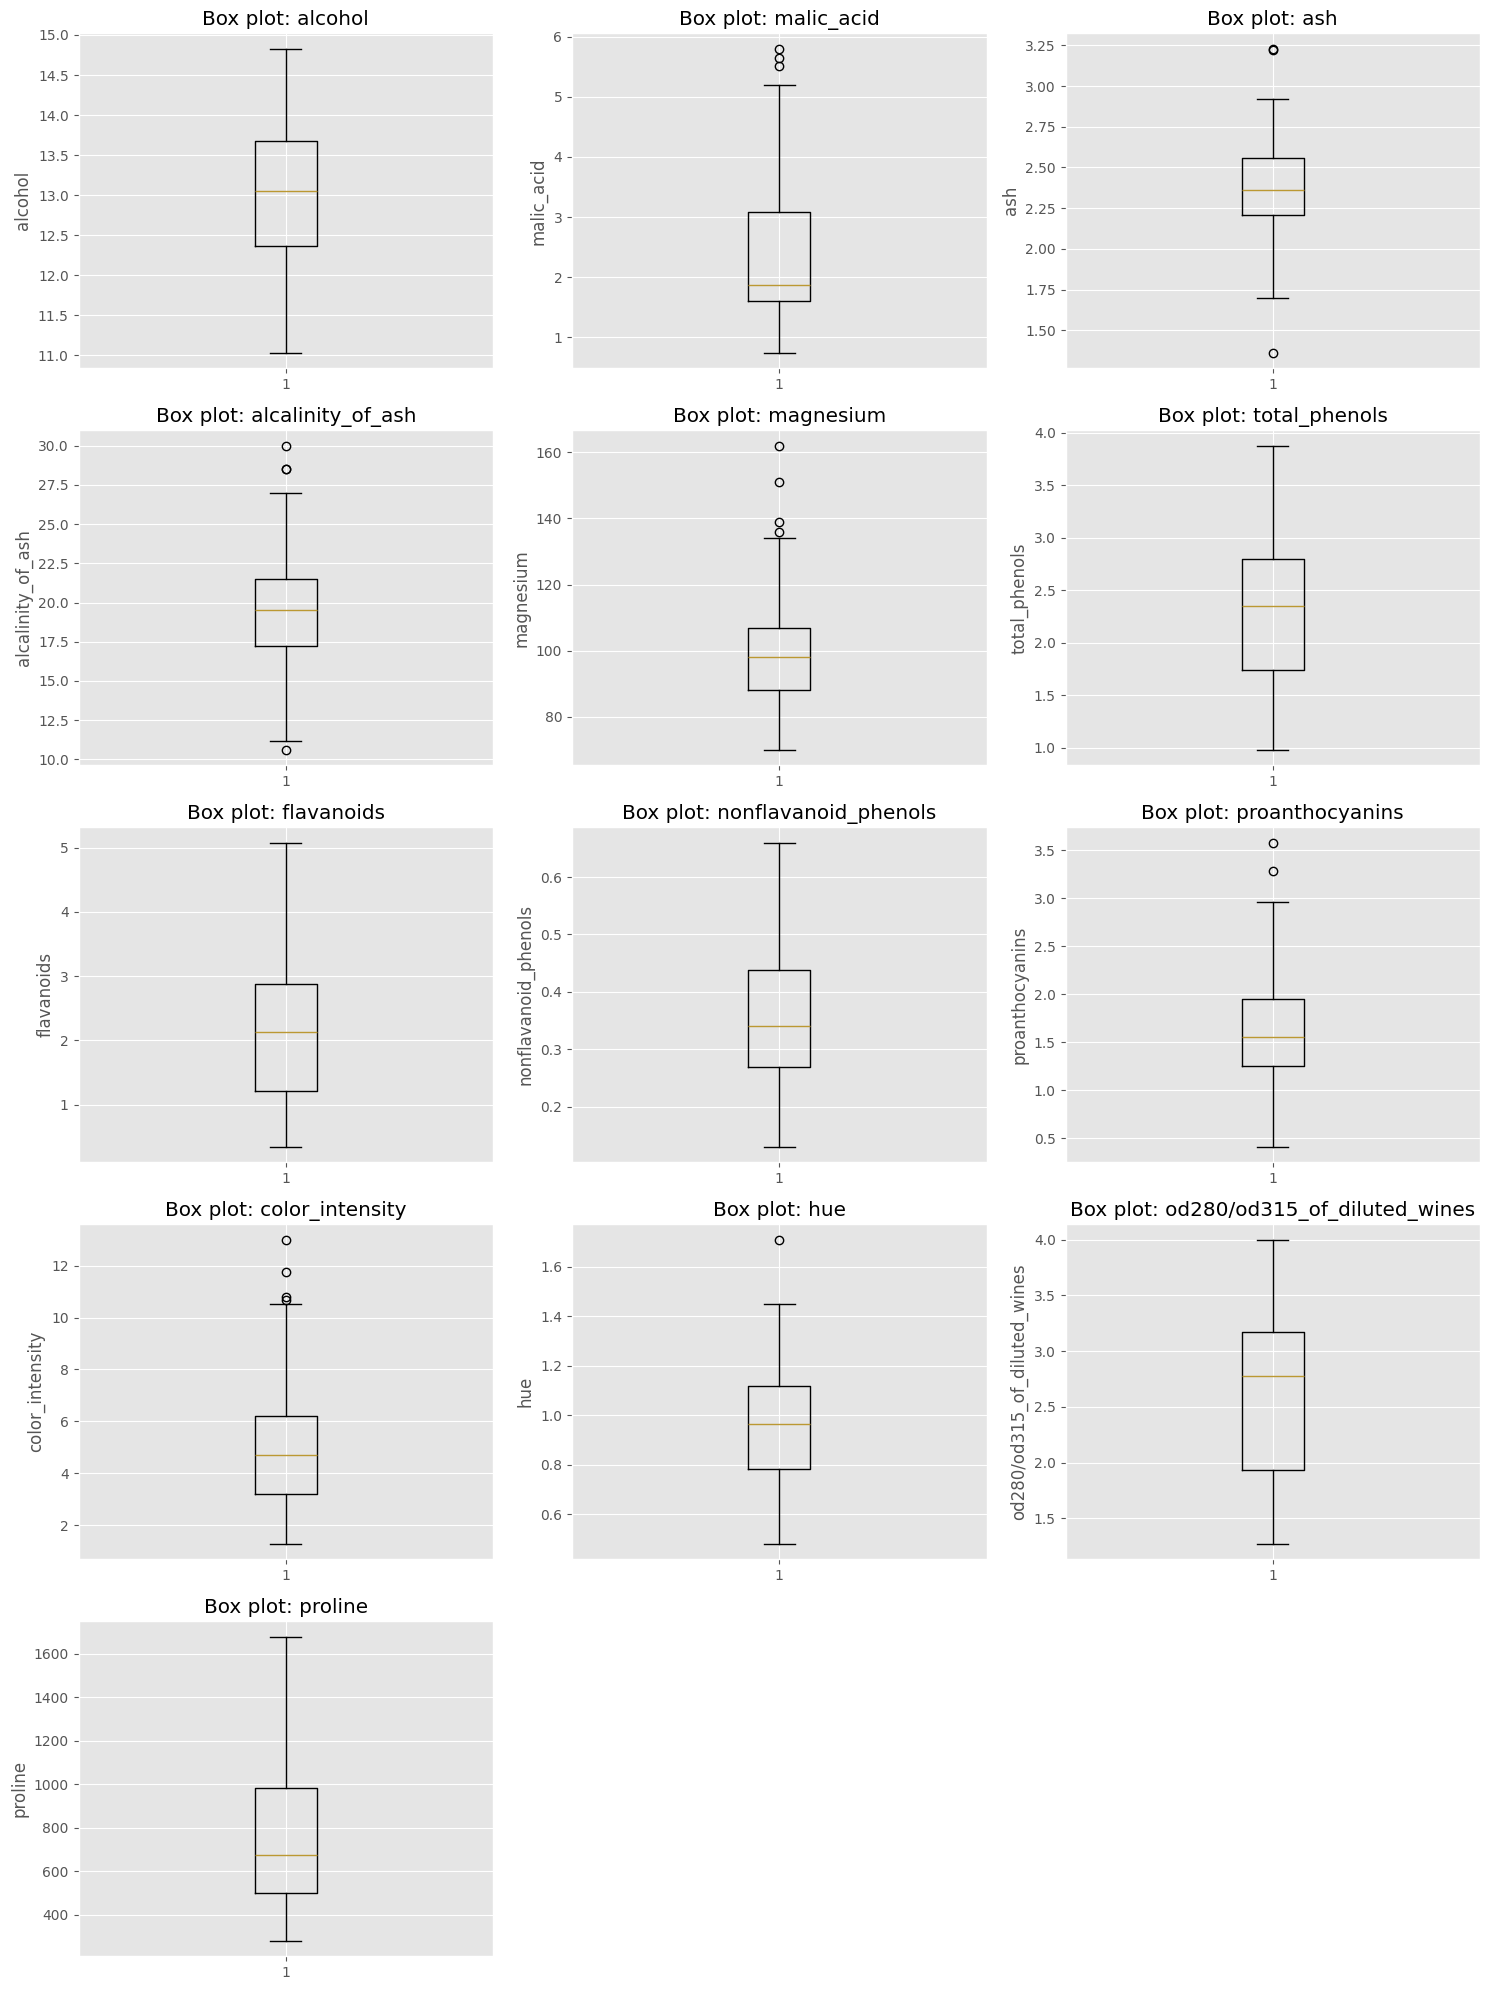

In [13]:
# 3.2 Box plots для визуализации выбросов
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.ravel()

for idx, feature in enumerate(wine.feature_names):
    axes[idx].boxplot(df[feature])
    axes[idx].set_title(f'Box plot: {feature}')
    axes[idx].set_ylabel(feature)

for idx in range(len(wine.feature_names), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


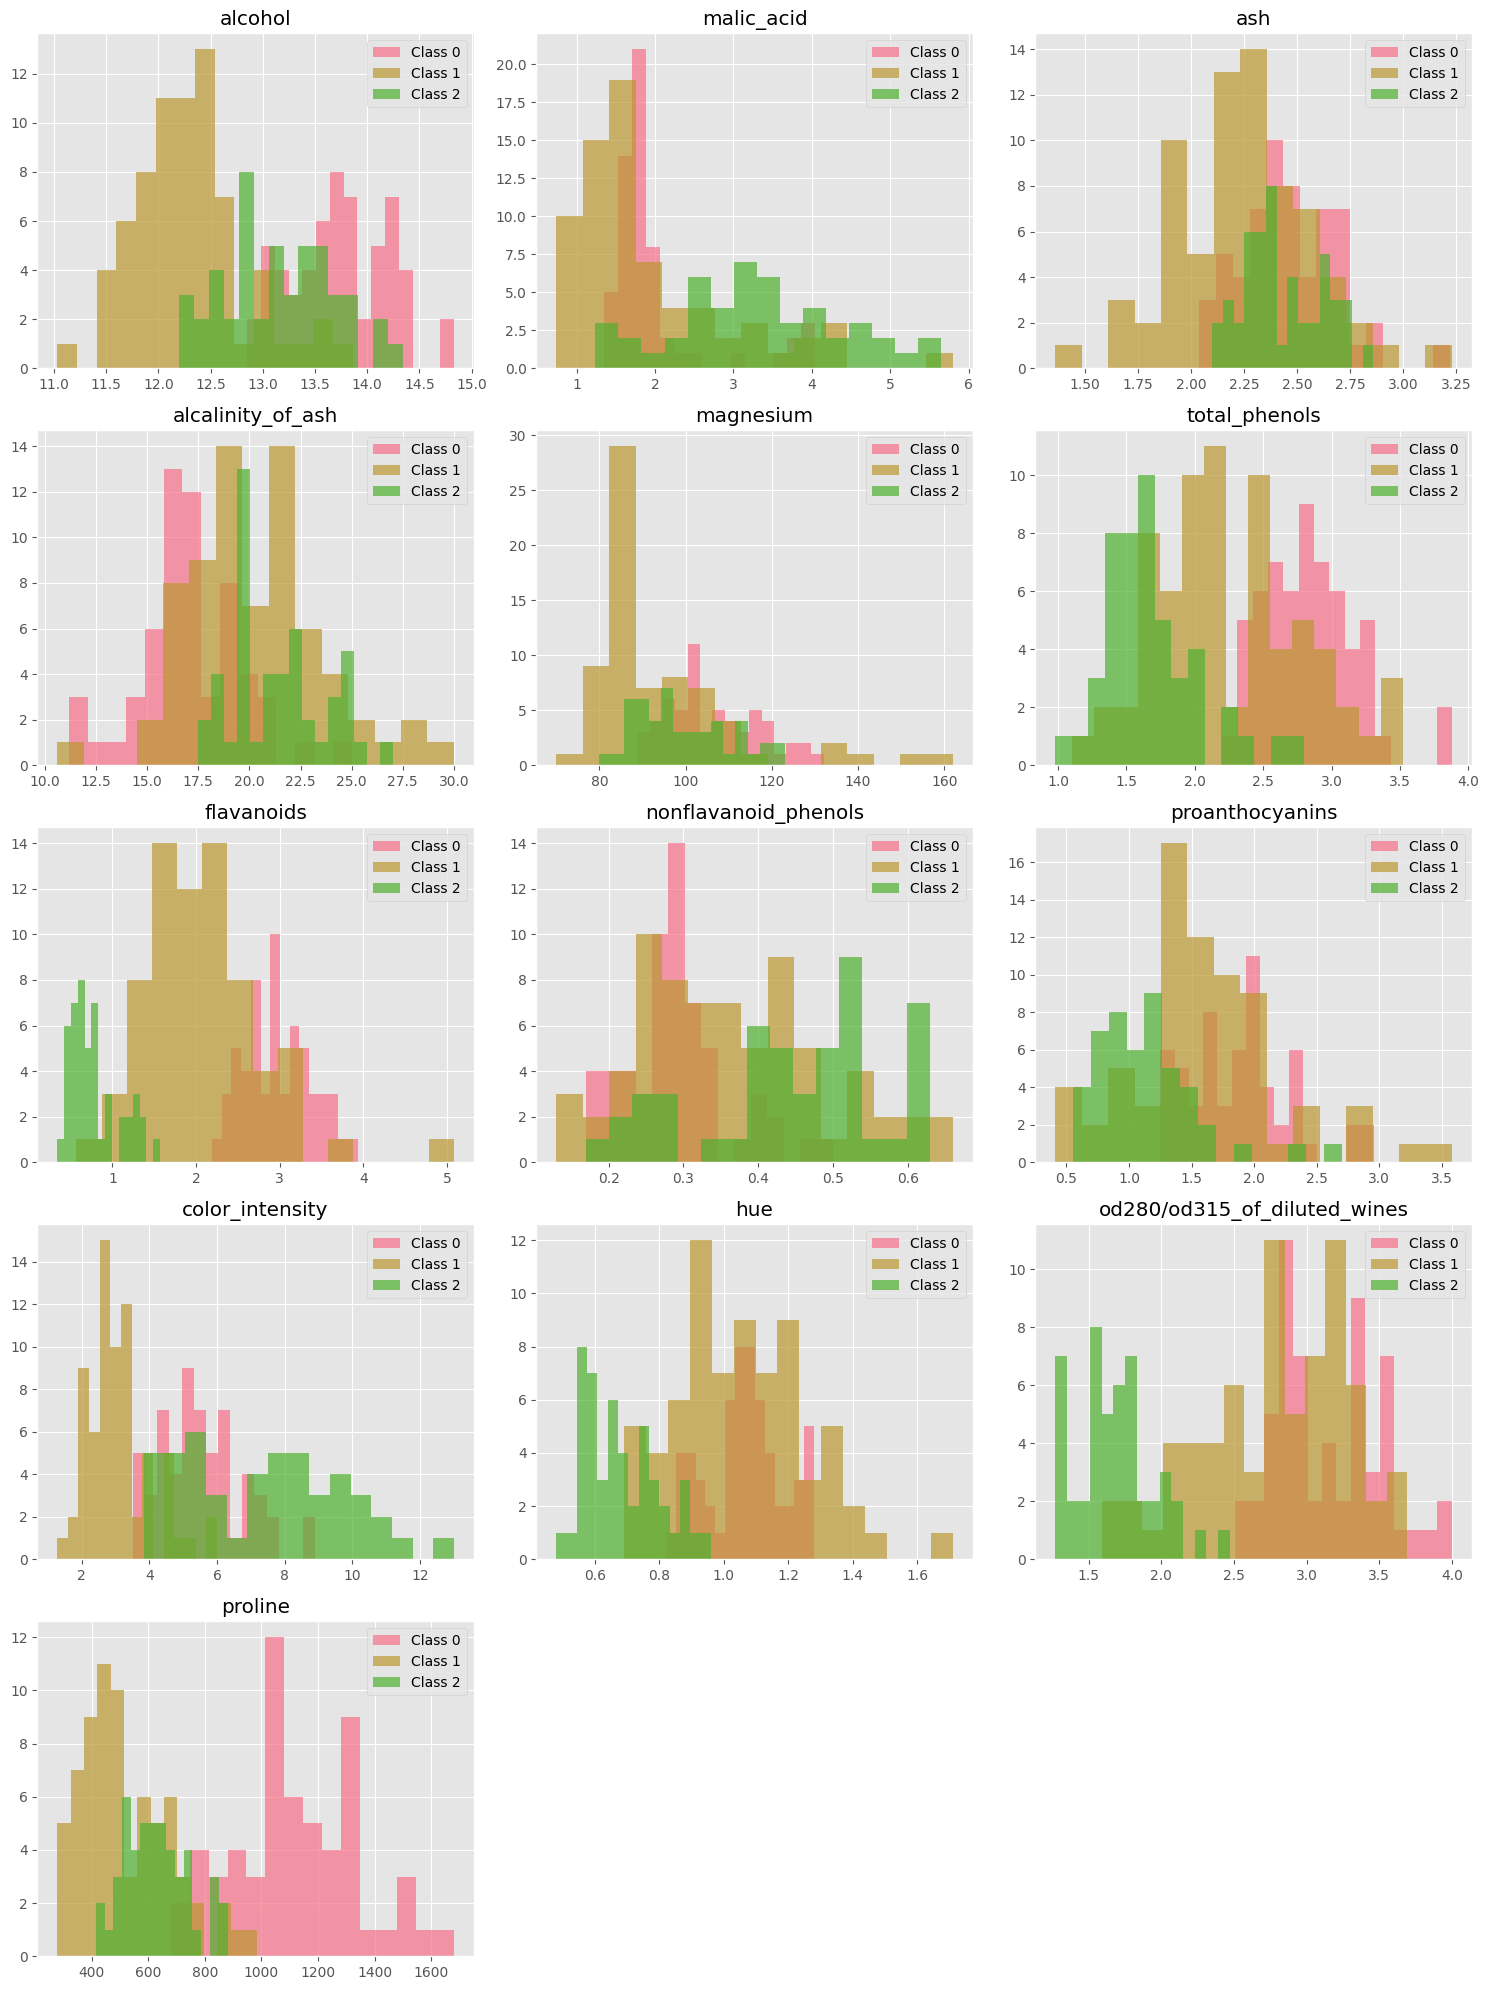

In [14]:
# 3.3 Распределение признаков по классам
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.ravel()

for idx, feature in enumerate(wine.feature_names):
    for target in sorted(df['target'].unique()):
        data = df[df['target'] == target][feature]
        axes[idx].hist(data, bins=15, alpha=0.7, label=f'Class {target}')
    axes[idx].set_title(feature)
    axes[idx].legend()

for idx in range(len(wine.feature_names), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 4. Информация о корреляции признаков

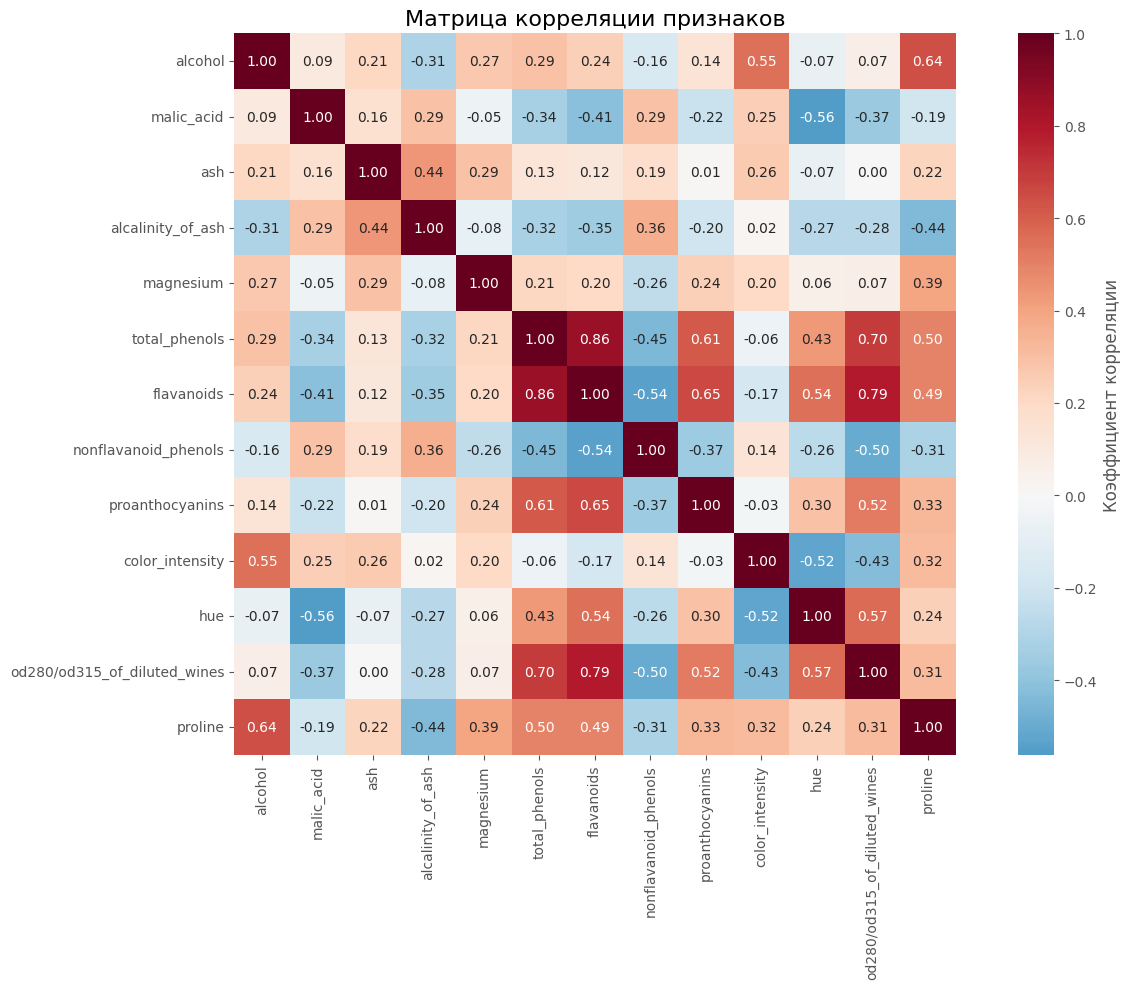

In [20]:
# 4.1 Матрица корреляции
correlation_matrix = df[wine.feature_names].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Матрица корреляции признаков', fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
# 4.2 Топ-10 самых сильных корреляций
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
corr_pairs = correlation_matrix.where(mask).stack().reset_index()
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']
corr_pairs['abs_corr'] = abs(corr_pairs['Корреляция'])
top_correlations = corr_pairs.nlargest(10, 'abs_corr')[['Признак 1', 'Признак 2', 'Корреляция']]

display(top_correlations)

,Признак 1,Признак 2,Корреляция
50,total_phenols,flavanoids,0.864564
61,flavanoids,od280/od315_of_diluted_wines,0.787194
55,total_phenols,od280/od315_of_diluted_wines,0.699949
58,flavanoids,proanthocyanins,0.652692
11,alcohol,proline,0.643720
52,total_phenols,proanthocyanins,0.612413
75,hue,od280/od315_of_diluted_wines,0.565468
20,malic_acid,hue,-0.561296
8,alcohol,color_intensity,0.546364
60,flavanoids,hue,0.543479
